# =========================================
# GI SPATIAL ANALYSIS – GDANSK
# =========================================

Author: Khansa Gulshad

Paper: Biophysical and sociodemographic determinants of green infrastructure spatial distribution in Gdańsk, Poland

Journal: *Scientific Reports*

This notebook reproduces the spatial analysis conducted in the study, including spatial autocorrelation, regression modelling, and priority mapping of green infrastructure (GI).

All analyses are performed at a 1 km grid resolution to ensure consistency across datasets and enable city-wide comparison.

## Reproducibility Note

All results, figures, and tables presented in the study can be reproduced by running this notebook sequentially. The workflow follows a structured pipeline from data preprocessing to spatial modelling and priority mapping.

In [4]:
#Import or install all required libraries
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import libpysal
from pysal.model import spreg
from spreg import ML_Lag, ML_Error
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW
import pingouin as pg
import pandas.testing as tm
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from mgwr.utils import shift_colormap, truncate_colormap
import matplotlib.patches as mpatches

# Data Preparation

Import GI density data and independent factors dataset.
This section loads and preprocesses all spatial datasets used in the analysis.

All variables are aggregated or resampled to a common 1 km grid to ensure spatial comparability. The datasets include biophysical factors (elevation, NDVI), built environment variables (impervious surface, infrastructure proximity), socio-demographic indicators (population density, elderly population), environmental stressors (LST, NO₂, O₃), and hazard data (flood occurrence).

The resulting GeoDataFrame serves as the input for all subsequent analyses.

In [ ]:
GI=gpd.read_file('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/GI_grid_scale_density.geojson')

In [ ]:
GI=GI.to_crs('EPSG:4326')

In [ ]:
# Assuming GI density is already calculated and stored in grid_gdf['GI_density']
# Define the bin edges for the legend ranges
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8]

# Create a normalized colormap for the GI density
norm = mcolors.BoundaryNorm(bins, ncolors=256)
cmap = plt.cm.YlGnBu

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the grid with GI density using the 'YlGnBu' colormap
GI.plot(column='GI_density', cmap=cmap, linewidth=0, ax=ax, edgecolor='0.8', legend=False)

# Add a custom legend for the bins
legend_labels = [f"{bins[i]:.2f} - {bins[i+1]:.2f}" for i in range(len(bins)-1)]
legend_colors = [cmap(norm(b)) for b in bins[:-1]]  # Get colors corresponding to bins

# Plot a scatter plot for the custom legend
for label, color in zip(legend_labels, legend_colors):
    ax.scatter([], [], c=[color], label=label, edgecolors='none', s=50)

# Add the legend to the plot
ax.legend(scatterpoints=1, frameon=False, labelspacing=1, title='GI Density', bbox_to_anchor=(1, 1))

# Display the plot
plt.show()
# fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/gi_density_grid.jpg',bbox_inches="tight", dpi=300)
# files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/gi_density_grid.jpg")

### Independent factors import

In [ ]:
# Read the shapefile
DEM = gpd.read_file("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/DEM.shp")

# Convert to GeoJSON
DEM.to_file("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/DEM.geojson", driver="GeoJSON")

# print("Conversion complete!")

In [ ]:
DEM=gpd.read_file('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/DEM.geojson')

In [ ]:
DEM=DEM.to_crs('EPSG:4326')

In [ ]:
# Visualize GI Density
import numpy as np

# Calculate quantiles for bin edges
quantiles =DEM['DEM_mean'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Use the same colormap for both the map and the legend
colormap = plt.cm.Greens  # Use the 'Greens' colormap for consistency

# Visualize GI Density with legend representing ranges
fig, ax = plt.subplots(figsize=(10, 10))
# gdf_admin.plot(column='GI_density', cmap='YlGnBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True, legend_kwds={'label': "Green Infrastructure Density", 'orientation': "horizontal", 'pad': 0.01})
DEM.plot(column='DEM_mean', cmap=colormap, linewidth=0.8, ax=ax, edgecolor='0.8', legend=False)

# Create custom legend with ranges
legend_labels = [f"{quantiles.values[i]:.2f} - {quantiles.values[i+1]:.2f}" for i in range(len(quantiles)-1)]
legend_colors = colormap(np.linspace(0, 1, len(quantiles)-1))


for label, color in zip(legend_labels, legend_colors):
    ax.scatter([], [], c=[color], label=label, edgecolors='none', s=50)

ax.legend(scatterpoints=1, frameon=False, labelspacing=1, title='DEM', bbox_to_anchor=(1, 1))

# plt.title('Green Infrastructure Density Choropleth Map')
plt.show()
# fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/dem_grid.jpg',bbox_inches="tight", dpi=300)
# files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/dem_grid.jpg")

In [ ]:
# Read the shapefile
ndvi = gpd.read_file("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/ndvi.shp")

# Convert to GeoJSON
ndvi.to_file("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/ndvi.geojson", driver="GeoJSON")

print("Conversion complete!")

Conversion complete!


In [ ]:
ndvi=gpd.read_file('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/ndvi.geojson')

In [ ]:
# Visualize GI Density
import numpy as np

# Calculate quantiles for bin edges
quantiles =ndvi['ndvi_mean'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Use the same colormap for both the map and the legend
colormap = plt.cm.Greens  # Use the 'Greens' colormap for consistency

# Visualize GI Density with legend representing ranges
fig, ax = plt.subplots(figsize=(10, 10))
# gdf_admin.plot(column='GI_density', cmap='YlGnBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True, legend_kwds={'label': "Green Infrastructure Density", 'orientation': "horizontal", 'pad': 0.01})
ndvi.plot(column='ndvi_mean', cmap=colormap, linewidth=0.8, ax=ax, edgecolor='0.8', legend=False)

# Create custom legend with ranges
legend_labels = [f"{quantiles.values[i]:.2f} - {quantiles.values[i+1]:.2f}" for i in range(len(quantiles)-1)]
legend_colors = colormap(np.linspace(0, 1, len(quantiles)-1))


for label, color in zip(legend_labels, legend_colors):
    ax.scatter([], [], c=[color], label=label, edgecolors='none', s=50)

ax.legend(scatterpoints=1, frameon=False, labelspacing=1, title='NDVI', bbox_to_anchor=(1, 1))

# plt.title('Green Infrastructure Density Choropleth Map')
plt.show()
# fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/ndvi_grid.jpg',bbox_inches="tight", dpi=300)
# files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/ndvi_grid.jpg")

Repeat the same process for all other factors for import. e.g., elevation, impervious surface, infrastructure proximity, population density, elderly population, LST, NO₂, O₃, flood occurrence, particulate matter, future precipitation, river and rainwater collectors.

Combine all factors

In [ ]:
# Assuming you have a list of GeoDataFrames you want to merge
geo_dfs = [elderly,river,rainw,ozone,pm10,nox,pm25_21,pop_den,DEM,lst,ndvi,imper,flood,pr1_21_50,pr1_71_2100, pr2_21_50, pr2_71_2100, health, educ, indus ]  # Replace gdf1, gdf2, gdf3 with your actual GeoDataFrames

def custom_merge(x, y):
    # Identify common columns except for the joining key and 'geometry'
    common_columns = set(x.columns).intersection(set(y.columns)) - {'PageNumber'}

    # Drop common columns from the right DataFrame (y) before the merge
    y = y.drop(columns=list(common_columns))

    # Perform the merge
    return pd.merge(x, y, on='PageNumber', how='outer')

# Use reduce with the custom_merge function to combine all GeoDataFrames
combined_gdf = reduce(custom_merge, geo_dfs)

# Ensure the result is a GeoDataFrame
combined_gdf = gpd.GeoDataFrame(combined_gdf, geometry='geometry')

# Now combined_gdf is a single GeoDataFrame containing all the merged data
# with duplicate columns dropped (except for the first occurrence).


In [ ]:
combined_gdf.to_file('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/combined_gdf.geojson', driver='GeoJSON')

In [ ]:
combined_gdf_copy=gpd.read_file('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/combined_gdf_copy.geojson')

#### Normalization

In [ ]:
combined_gdf_norm = combined_gdf_copy.copy()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Assuming combined_gdf is your combined GeoDataFrame and factor_columns are the columns you want to normalize
factor_columns = ['elderly_mean', 'river_mean', 'rainw_mean', 'ozone_mean', 'pm10_mean',
       'nox_mean', 'pm25_21_mean', 'pop_den_mean', 'DEM_mean', 'lst_mean',
       'ndvi_mean', 'imper_area', 'flood_count', 'pr1_21_50_mean',
       'pr1_71_2100_mean', 'pr2_21_50_mean', 'pr2_71_2100_mean','health_mean',
       'educ_mean', 'indus_mean']  # Replace with your actual factor column names

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
combined_gdf_norm[factor_columns] = scaler.fit_transform(combined_gdf_norm[factor_columns])

# Your factors are now normalized and stored in combined_gdf_norm

In [ ]:
combined_gdf_norm.to_file('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/combined_gdf_norm.geojson', driver='GeoJSON')

In [ ]:
combined_gdf_norm=gpd.read_file('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/combined_gdf_norm.geojson')

In [ ]:
# Create a copy of the GeoDataFrame before dropping columns
dep_indep_norm = combined_gdf_norm.copy()

# List of columns you want to drop from the combined GeoDataFrame
columns_to_drop = ['PageNumber', 'Area_grid', 'AREA', 'AREA_1','geometry']  # Replace these with actual column names you want to remove
# Drop the columns
dep_indep_norm = dep_indep_norm.drop(columns=columns_to_drop)

# Now dep_indep_norm has the specified columns removed

In [ ]:
dep_indep_norm.to_csv("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/dep_indep_norm.csv")

### Correlation Analysis

In [ ]:
selected_columns = combined_gdf_norm[['elderly_mean', 'river_mean', 'rainw_mean', 'ozone_mean', 'pm10_mean',
       'nox_mean', 'pm25_21_mean', 'pop_den_mean', 'DEM_mean', 'lst_mean',
       'ndvi_mean', 'imper_area', 'flood_count', 'pr1_21_50_mean',
       'pr1_71_2100_mean', 'pr2_21_50_mean', 'pr2_71_2100_mean', 'health_mean',
       'educ_mean', 'indus_mean']]
indep_data_norm=selected_columns.copy()
indep_data_norm.head()

In [ ]:
dep_data_non_norm=combined_gdf_copy[['GI_density']]

In [ ]:
dep_data_non_norm.head()

For corrrelation matrix

In [ ]:
# lets check correlation for all factors (continous,discrete)
fig=plt.figure(figsize=(15,12))
matrix = np.triu(indep_data_norm.corr())
# cor = combine.corr()
sns.heatmap(indep_data_norm.corr(), cmap='magma', linecolor='white',linewidths=1, annot=True, fmt='.1g', cbar_kws= {'orientation': 'vertical'}, mask=matrix )
plt.title('Correlation Matrix', fontsize=17)
plt.xlabel("Factors", labelpad=4)
plt.ylabel("Factors")
# fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/correlation_mat1.jpg',bbox_inches="tight", dpi=300)
# files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/correlation_mat1.jpg")

Correlation with output variable GI density

In [ ]:
#Correlation with output variable
combine[combine.columns[1:]].corr()['GI_density'][:]

To plot highly correlated variables only in matrix and plot correlation with GI density

In [ ]:
name_map = {
    'elderly_mean': 'Elderly pop.',
    'river_mean': 'River dist.',
    'rainw_mean': 'Rainwater dist.',
    'ozone_mean': 'O$_3$',
    'pm10_mean': 'PM$_{10}$',
    'pm25_21_mean': 'PM$_{2.5}$',
    'nox_mean': 'NO$_2$',
    'pop_den_mean': 'Pop. density',
    'DEM_mean': 'DEM',
    'lst_mean': 'LST',
    'ndvi_mean': 'NDVI',
    'imper_area': 'Impervious area',
    'flood_count': 'Flood',
    'pr1_21_50_mean': 'PR1',
    'pr1_71_2100_mean': 'PR2',
    'pr2_21_50_mean': 'PR3',
    'pr2_71_2100_mean': 'PR4',
    'health_mean': 'Health dist.',
    'educ_mean': 'Education dist.',
    'indus_mean': 'Industry dist.',
    'GI_density': 'GI density'
}


# --- HEATMAP PREPARATION ---
corr = indep_data_norm.corr()
filteredDf = corr[((corr >= 0.5) | (corr <= -0.5)) & (corr != 1.000) & (corr >= -0.9)]

# rename AFTER filtering (heatmap)
filteredDf = filteredDf.rename(index=name_map, columns=name_map)

# --- BARPLOT PREPARATION ---
dep_var = 'GI_density'
correlation_with_gi = dep_indep_norm.corr()[dep_var].drop(dep_var)
p_values = calculate_pvalues_with_gi(dep_indep_norm, dep_var)

results = pd.DataFrame({
    'Correlation Coefficient': correlation_with_gi,
    'P-Value': p_values.drop(dep_var)
})

# rename AFTER constructing results (barplot)
results.index = results.index.map(name_map)

# Create a mask for the upper triangle
mask_upper = np.triu(np.ones_like(filteredDf, dtype=bool))


fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(filteredDf, annot=True, cmap="Reds", mask=mask_upper, ax=ax)
ax.set_title('Correlation Matrix', fontsize=18)
ax.set_xlabel("Factors", fontsize=14)
ax.set_ylabel("Factors", fontsize=14)

# x labels
ax.set_xticks(range(len(filteredDf.columns)))
ax.set_xticklabels(filteredDf.columns, rotation=45, ha='right', fontsize=14)

# y labels (your missing step)
ax.set_yticks(range(len(filteredDf.index)))
ax.set_yticklabels(filteredDf.index, fontsize=14)

plt.tight_layout()
plt.show()


# Optional: Save the figure
fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/correlation_plot.jpg', bbox_inches="tight", dpi=400)
files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/correlation_plot.jpg")

fig, ax = plt.subplots(figsize=(10, 6))

bars = sns.barplot(x=results.index, y='Correlation Coefficient', data=results, ax=ax)

# Colors
for i, bar in enumerate(bars.patches):
    if results['Correlation Coefficient'][i] < 0:
        bar.set_color('#f55f64')  # Negative
    else:
        bar.set_color('#800e8c')  # Positive

ax.set_title('Correlation with GI Density', fontsize=18)
ax.set_ylabel('Correlation Coefficient', fontsize=14)
ax.set_xlabel('Factors', fontsize=14)
ax.set_xticks(range(len(results.index)))
ax.set_xticklabels(results.index, rotation=45, ha='right', fontsize=14)

plt.tight_layout()
plt.show()

# Optional: Save the figure
fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/bar_correlation_plot.jpg', bbox_inches="tight", dpi=400)
files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/bar_correlation_plot.jpg")

#### Partial correlation

In [ ]:
# --- Partial Correlation Tests ---

# Test A: Does population density still matter when impervious is controlled?
test_pop_given_imper = pg.partial_corr(
    data=combined_gdf_norm,
    x='GI_density',
    y='pop_den_mean',
    covar='imper_area',
    method='pearson'
)

# Test B: Does impervious surface still matter when population is controlled?
test_imper_given_pop = pg.partial_corr(
    data=combined_gdf_norm,
    x='GI_density',
    y='imper_area',
    covar='pop_den_mean',
    method='pearson'
)

print("Test A — GI vs Population | Impervious controlled")
print(test_pop_given_imper, "\n")

print("Test B — GI vs Impervious | Population controlled")
print(test_imper_given_pop)



### Multicollinearity Test

In [ ]:
#add constant
indep_data_norm2=indep_data_norm
x_data_const=add_constant(indep_data_norm2) # adding constant

In [ ]:
def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [ ]:
X = x_data_const
calc_vif(X) #VIF values for PM_10_mean and pm_25_21_mean, pr1_21_50_mean are larger than 4, therefore these need to be removed as they also got high correlation

In [ ]:
#so let's drop one of these variables and see VIF value changes
x_data_const=x_data_const.drop(['pm25_21_mean', 'pr1_21_50_mean'], axis=1)

In [ ]:
X = x_data_const
calc_vif(X) # see VIF is now better

In [ ]:
VIF_values = pd.DataFrame(calc_vif(X)) # convert VIF values table to dataframe and then save to .csv file

In [ ]:
VIF_values.to_csv("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/VIF_values.csv",index=False)

# Spatial Autocorrelation

This section evaluates whether GI density exhibits spatial clustering across the study area.

Global Moran’s I is used to assess overall spatial dependence, indicating whether similar values cluster together across the city.

Local Moran’s I (LISA) is then applied to identify localized clusters and spatial outliers (high-high, low-low, high-low, low-high). Multiple spatial weight matrices were tested, and the most appropriate configuration was selected based on statistical performance.

This analysis establishes whether spatial modelling approaches are required.

### Global Moran's I

In [ ]:
# Define weights
weights_list = {
    "Adaptive KNN": KNN.from_dataframe(GI, k=int(np.sqrt(len(GI)))),
    "Fixed KNN (k=8)": KNN.from_dataframe(GI, k=8),
    "Queen Contiguity": Queen.from_dataframe(GI),
    "Rook Contiguity": Rook.from_dataframe(GI),
    "Distance Band (500m)": DistanceBand.from_dataframe(GI, threshold=500)
}

results = {}

for key, w in weights_list.items():
    w.transform = 'R'

    # Compute Global Moran's I
    moran_global = Moran(GI['GI_density'], w)

    # Compute Local Moran's I
    lisa = Moran_Local(GI['GI_density'], w)

    # Store Moran's I values separately
    results[key] = {
        "Local Moran's I Mean": np.mean(lisa.Is),  # Mean of local I values
        "Global Moran's I": moran_global.I,  # Global Moran's I

        # Separate p-values for Global and Local Moran
        "p-value (Global Moran)": moran_global.p_sim,
        "% Significant Cells (Local Moran)": np.mean(lisa.p_sim < 0.05) * 100
    }

# Convert results to DataFrame
df_results = pd.DataFrame(results).T

# Print formatted results
df_results


In [ ]:
# Print formatted results
df_results


In [ ]:
# from libpysal.weights import Rook
w_rook = Rook.from_dataframe(GI)
w_rook.transform = 'R'

In [ ]:
moran = esda.moran.Moran(GI['GI_density'], w_rook)

In [ ]:
round(moran.I,3)

In [ ]:
gi_density = GI['GI_density']

In [ ]:
# Decide on the neighbors
# For k=4 or k=8 (you can switch between KNN for nearest neighbors and Queen for contiguity-based neighbors)
k_neighbors = 8  # Change to 8 for k=8

# # Create a K-nearest neighbor spatial weights matrix (for k-nearest neighbors)
# knn_weights = KNN.from_dataframe(GI, k=k_neighbors)

# Calculate Moran's I
moran = Moran(gi_density, w_rook)

# Print Moran's I value
print(f"Moran's I value for k={w_rook}: {round(moran.I, 3)}")

# Monte Carlo significance test (999 permutations)
# Run Monte Carlo simulation to get the p-value and Z-score
print(f"p-value: {moran.p_sim}")
print(f"Z-score: {moran.z_sim}")

# Plot the permutation distribution and observed Moran's I
plt.hist(moran.sim, bins=30, alpha=0.75, color='blue')
plt.axvline(moran.I, color='red', linestyle='dashed', linewidth=2)
plt.title(f'Monte Carlo Simulation for Moran\'s I (k={w_rook})')
plt.xlabel('Simulated Moran\'s I')
plt.ylabel('Frequency')
plt.show()

In [ ]:
fig, ax= moran_scatterplot(moran, aspect_equal=True)
plt.show()
# fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/global_moran_scat_grid.jpg',bbox_inches="tight", dpi=300)
# files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/global_moran_scat_grid.jpg")

In [ ]:
moran.p_sim

In [ ]:
test2=plt.hist(moran.sim, 10, facecolor='lightblue', edgecolor='black')
plt.vlines(moran.I, 0, 350, color='r', linestyle="--")
plt.vlines(moran.EI, 0, 350)
plt.xlabel("Moran's I")
plt.ylabel("Count")
# Get the current figure before showing it
fig = plt.gcf()
plt.show()
# fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/global_moran_hits_grid.jpg',bbox_inches="tight", dpi=300)
# files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/global_moran_hits_grid.jpg")

#### Global Moran Plots

In [ ]:
GI['GI_density_lag'] = weights.spatial_lag.lag_spatial(w_rook, GI['GI_density'])

In [ ]:
def standardize(df, var):

    newname = var + '_z'
    df[newname] = (df[var] - df[var].mean()) / df[var].std()

standardize(GI,'GI_density')
standardize(GI,'GI_density_lag')

In [ ]:
def rules(row):
    if row['GI_density_z'] > 0:
        if row['GI_density_lag_z'] > 0:
            return 'HH'
        else:
            return 'HL'
    else:
        if row['GI_density_lag_z'] > 0:
            return 'LH'
        else:
            return 'LL'

GI['quadrant'] = GI.apply(rules, 1)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={'width_ratios': [2, 1]})

qcolors = {'HH':'red', 'HL':'pink', 'LH':'lightblue', 'LL':'blue'}

#map
GI.plot(column='quadrant', categorical=True, cmap=colors.ListedColormap(qcolors.values()),
         k=2, edgecolor='white', linewidth=0.2,
         legend=True, legend_kwds={"title":'Global Moran I',"loc": 'upper left', 'bbox_to_anchor': (0.75, 1), 'ncol': 1},
         ax=ax[0])

#scatter plot
ax[1].scatter(GI['GI_density_z'], GI['GI_density_lag_z'], c=GI['quadrant'].map(qcolors))
ax[1].axvline(0, c='k', alpha=0.5)
ax[1].axhline(0, c='k', alpha=0.5)
ax[1].set_xlabel("GI % (z)")
ax[1].set_ylabel("Local Mean GI % (z)")

plt.show()
# fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/global_moran_ll_hh_map_grid.jpg',bbox_inches="tight", dpi=300)
# files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/global_moran_ll_hh_map_grid.jpg")

### Local Moran's I

In [5]:
# compute sptaial lag with adpative weights for local
# Step 1: Compute Adaptive KNN Weights
k_adaptive = int(np.sqrt(len(GI)))  # Adaptive k based on sqrt of total observations
w_adaptive = weights.KNN.from_dataframe(GI, k=k_adaptive)
w_adaptive.transform = 'R'  # Row-standardization to ensure sum = 1

#1st
# from libpysal.weights import Queen

# w_queen = Queen.from_dataframe(GI)
# w_queen.transform = 'R'  # Row-standardization

#2nd
# from libpysal.weights import Rook
# w_rook = Rook.from_dataframe(GI)
# w_rook.transform = 'R'

#3rd
# from libpysal.weights import DistanceBand

# w_distance = DistanceBand.from_dataframe(GI, threshold=500)
# w_distance.transform = 'R'

In [ ]:
GI['GI_density_lag_adaptive'] = weights.spatial_lag.lag_spatial(w_adaptive, GI['GI_density'])

# Standardize the new lag variable
standardize(GI, 'GI_density_lag_adaptive')

# Now use this for Local Moran’s I
lisa = Moran_Local(GI['GI_density'], w_adaptive)


In [ ]:
# Step 3: Add Local Moran's I results to the GeoDataFrame
GI['local_I'] = lisa.Is  # Local Moran's I values
GI['p_sim'] = lisa.p_sim  # P-values from permutation
GI['significant'] = GI['p_sim'] < 0.05  # Significant clusters (p < 0.05)

# Step 4: Compute new lag using the adaptive weight matrix
GI['GI_density_lag_adaptive'] = weights.spatial_lag.lag_spatial(w_adaptive, GI['GI_density'])

# Step 5: Standardize the new lagged GI density
standardize(GI, 'GI_density_lag_adaptive')  # This creates 'GI_density_lag_adaptive_z'

# Step 6: Define Moran's I Quadrants using the correct lag variable
GI['quadrant'] = 'Non-significant'
GI.loc[(GI['significant']) & (GI['GI_density_z'] > 0) & (GI['GI_density_lag_adaptive_z'] > 0), 'quadrant'] = 'HH'
GI.loc[(GI['significant']) & (GI['GI_density_z'] < 0) & (GI['GI_density_lag_adaptive_z'] < 0), 'quadrant'] = 'LL'
GI.loc[(GI['significant']) & (GI['GI_density_z'] > 0) & (GI['GI_density_lag_adaptive_z'] < 0), 'quadrant'] = 'HL'
GI.loc[(GI['significant']) & (GI['GI_density_z'] < 0) & (GI['GI_density_lag_adaptive_z'] > 0), 'quadrant'] = 'LH'

# Step 7: Define Colors for Quadrants
qcolors = {'HH': 'red', 'LL': 'blue', 'HL': 'pink', 'LH': 'lightblue', 'Non-significant': 'lightgrey'}

# Step 8: Plot the Results
fig, ax = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={'width_ratios': [2, 1]})

# Map: Moran's I Quadrants
GI.plot(column='quadrant', categorical=True, cmap=colors.ListedColormap(qcolors.values()),
        edgecolor='white', linewidth=0.2, legend=True,
        legend_kwds={"title": "Local Moran's I Quadrants", "loc": "upper right" },
        ax=ax[0])
ax[0].set_title("Local Moran's I - Spatial Clusters")

# Scatter Plot: Moran Scatterplot
ax[1].scatter(GI['GI_density_z'], GI['GI_density_lag_adaptive_z'], c=GI['quadrant'].map(qcolors),
              edgecolor='k', alpha=0.7)
ax[1].axvline(0, color='k', linestyle='--', alpha=0.5)
ax[1].axhline(0, color='k', linestyle='--', alpha=0.5)
ax[1].set_title("Moran's I Scatterplot")
ax[1].set_xlabel("GI Density (z-score)")
ax[1].set_ylabel("Spatial Lag (z-score)")

# Adjust Layout and Show
fig.tight_layout()
plt.show()


# fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/local_moran_l_hh_map_grid.jpg',bbox_inches="tight", dpi=300)
# files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/local_moran_l_hh_map_grid.jpg")

# Global Regression (OLS, WLS, GLS)

This section implements global regression models to examine the relationship between GI density and explanatory variables.

Ordinary Least Squares (OLS) serves as a baseline model but assumes spatial independence. Due to detected heteroscedasticity and spatial autocorrelation, Weighted Least Squares (WLS) and Generalized Least Squares (GLS) are also applied.

These models provide initial estimates of relationships but do not fully account for spatial dependence.

to test using different weights method for each model

In [ ]:
from spreg import ML_Lag, ML_Error
from libpysal.weights import KNN, Queen, Rook, DistanceBand

# Define different weights matrices
weights_methods = {
    "Adaptive KNN": KNN.from_dataframe(combined_gdf_norm, k=int(np.sqrt(len(combined_gdf_norm)))),
    "Fixed KNN (k=8)": KNN.from_dataframe(combined_gdf_norm, k=8),
    "Queen Contiguity": Queen.from_dataframe(combined_gdf_norm),
    "Rook Contiguity": Rook.from_dataframe(combined_gdf_norm),
    "Distance Band (500m)": DistanceBand.from_dataframe(combined_gdf_norm, threshold=500)
}

# Standardizing the independent variables
scaler = StandardScaler()
X_standardized = scaler.fit_transform(combined_gdf_norm[factor_columns_2])
y = combined_gdf_norm['GI_density'].values

# Run models for each weights method
results = []
for name, w in weights_methods.items():
    w.transform = 'R'  # Row standardization

    # Spatial Lag Model
    lag_model = ML_Lag(y, X_standardized, w=w, name_ds='GI Density', name_w=name)

    # Spatial Error Model
    error_model = ML_Error(y, X_standardized, w=w, name_ds='GI Density', name_w=name)

    results.append({
        "Weights Method": name,
        "Spatial Lag R²": lag_model.pr2,
        "Spatial Lag AIC": lag_model.aic,
        "Spatial Lag Log-Likelihood": lag_model.logll,
        "Spatial Lag Rho (ρ)": lag_model.rho,
        "Spatial Error R²": error_model.pr2,
        "Spatial Error AIC": error_model.aic,
        "Spatial Error Log-Likelihood": error_model.logll,
        "Spatial Error Lambda (λ)": error_model.lam
    })

# Convert results into a DataFrame and display
results_df = pd.DataFrame(results)

to run without different weights methods

OLS

In [ ]:
# Assuming X and y are defined as per your dataset and combined_gdf_norm is your GeoDataFrame
X =combined_gdf_norm[factor_columns_2]
y = combined_gdf_norm['GI_density']

# Standardize the features (independent variables)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add a constant to the standardized variables for the intercept term
X_const_scaled = sm.add_constant(X_scaled)

# Fit the OLS model with standardized variables
model = sm.OLS(y, X_const_scaled).fit()

# Display the summary
print(model.summary())

# Save the summary to a CSV file (convert summary to DataFrame first)
results_ols_df = pd.read_html(model.summary().tables[1].as_html(),header=0,index_col=0)[0]
results_ols_df
results_ols_df.to_csv('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/OLS_Results.csv')


WLS

In [ ]:
# import statsmodels.api as sm
# import numpy as np

# # Assuming you've already fitted an OLS model and have residuals
# model_ols = sm.OLS(y, X).fit()
# residuals = model_ols.resid

# # Calculate weights as the inverse of the squared residuals
# weights = 1 / (residuals ** 2)

# # Fit a WLS model using these weights
# model_wls = sm.WLS(y, X, weights=weights).fit()

# # Print the WLS results
# print(model_wls.summary())
import statsmodels.api as sm
import numpy as np

# Refit OLS to get residuals
model_ols = sm.OLS(y, X).fit()
residuals = model_ols.resid

# Different weight calculations
weights_options = {
    "Inverse Squared Residuals": 1 / (residuals ** 2),
    "Inverse Absolute Residuals": 1 / np.abs(residuals),
    "Fitted Values": model_ols.fittedvalues
}

# Run WLS with different weights
for method, weights in weights_options.items():
    model_wls = sm.WLS(y, X, weights=weights).fit()
    print(f"\nWLS Results ({method}):")
    print(model_wls.summary())

GLS

In [ ]:
# Example of GLS with a known covariance structure (e.g., heteroscedasticity)
# Covariance matrix of the errors (Sigma) needs to be specified
# For simplicity, we'll use the identity matrix multiplied by the variance of residuals here
sigma = np.diag(residuals**2)  # Using residuals to estimate error variance

# Fit the GLS model
model_gls = sm.GLS(y, X, sigma=sigma).fit()

# Print the GLS results
print(model_gls.summary())


# Spatial Regression (SLM, SEM)

To account for spatial dependence, spatial econometric models are implemented.

The Spatial Lag Model (SLM) captures dependence in the dependent variable, reflecting spatial spillover effects.

The Spatial Error Model (SEM) accounts for spatial autocorrelation in residuals.

Multiple spatial weight matrices were tested, and the optimal configuration was selected based on model performance (AIC, R², log-likelihood). These models provide more reliable estimates in geographically structured data.

In [ ]:
# Now, assuming X and y are prepared, and w is the spatial weights matrix
X =combined_gdf_norm[factor_columns_2]
y = combined_gdf_norm['GI_density']

# # Use Adaptive KNN with sqrt(n) neighbors
# k_adaptive = int(np.sqrt(len(combined_gdf_norm)))  # Adaptive k based on dataset size
# w_adaptive = lps.weights.KNN.from_dataframe(combined_gdf_norm, k=k_adaptive)
# w_adaptive.transform = 'R'  # Row-standardization

# from libpysal.weights import DistanceBand
# w_distance = DistanceBand.from_dataframe(combined_gdf_norm, threshold=1000)
# w_distance.transform = 'R'

# from libpysal.weights import Queen

# w_queen = Queen.from_dataframe(combined_gdf_norm)
# w_queen.transform = 'R'


from libpysal.weights import Rook

w_rook_lag = Rook.from_dataframe(GI)
w_rook_lag.transform = 'R'

scaler = StandardScaler()

X_standardized = scaler.fit_transform(X)



ml_lag_model = ML_Lag(y, X_standardized , w=w_rook_lag,
                      name_y='GI_density',
                      name_x=['elderly_mean', 'river_mean', 'rainw_mean', 'ozone_mean', 'nox_mean', 'pop_den_mean',
              'DEM_mean', 'lst_mean', 'ndvi_mean', 'imper_area', 'flood_count', 'pr1_71_2100_mean',
              'pr2_21_50_mean', 'pr2_71_2100_mean', 'health_mean', 'educ_mean', 'indus_mean'],
                      name_ds='combined_gdf_norm')

print(ml_lag_model.summary)


In [ ]:
import numpy as np
import libpysal as lps
from spreg import ML_Error
from sklearn.preprocessing import StandardScaler

# Define dependent and independent variables
X = combined_gdf_norm[factor_columns_2]
y = combined_gdf_norm['GI_density']

# # Use Adaptive KNN with sqrt(n) neighbors
# k_adaptive = int(np.sqrt(len(combined_gdf_norm)))  # Adaptive k based on dataset size
# w_adaptive = lps.weights.KNN.from_dataframe(combined_gdf_norm, k=k_adaptive)
# w_adaptive.transform = 'R'  # Row-standardization

# from libpysal.weights import DistanceBand
# w_distance = DistanceBand.from_dataframe(combined_gdf_norm, threshold=1000)
# w_distance.transform = 'R'

# from libpysal.weights import Queen

# w_queen = Queen.from_dataframe(combined_gdf_norm)
# w_queen.transform = 'R'

# from libpysal.weights import Rook

w_rook_err = Rook.from_dataframe(GI)
w_rook_err.transform = 'R'

# Standardize the independent variables
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Define spatial error model using adaptive weights
ml_error_model = ML_Error(y, X_standardized, w=w_rook_err,
                          name_y='GI_density',
                          name_x=factor_columns_2,  # Ensure these names match DataFrame columns
                          name_w='Rook Spatial Weights',
                          name_ds='combined_gdf_norm')

# Print the model summary
print(ml_error_model.summary)

# Geographically weighted regression (GWR) (LOCAL MODEL)

In [ ]:
gdf_gwlr= combined_gdf_norm.copy()

In [ ]:
print(gdf_gwlr.columns)

Index(['PageNumber', 'Area_grid', 'GI_density', 'AREA', 'AREA_1',
       'elderly_mean', 'river_mean', 'rainw_mean', 'ozone_mean', 'pm10_mean',
       'nox_mean', 'pm25_21_mean', 'pop_den_mean', 'DEM_mean', 'lst_mean',
       'ndvi_mean', 'imper_area', 'flood_count', 'pr1_21_50_mean',
       'pr1_71_2100_mean', 'pr2_21_50_mean', 'pr2_71_2100_mean', 'health_mean',
       'educ_mean', 'indus_mean', 'geometry'],
      dtype='object')


In [ ]:
gdf_gwlr=gdf_gwlr.drop(['pm25_21_mean','pm10_mean', 'pr1_21_50_mean'], axis=1)

In [ ]:
import geopandas as gpd
import numpy as np
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from spglm.family import Binomial


# Calculate centroids for non-point geometries
gdf_gwlr['centroid'] = gdf_gwlr.geometry.centroid
centroids = np.array(list(map(lambda x: (x.x, x.y), gdf_gwlr.centroid)))

# Prepare the independent variables (X) and dependent variable (y)
# Standardize the independent variables to have mean=0 and variance=1
scaler = StandardScaler()
X = scaler.fit_transform(gdf_gwlr[['elderly_mean', 'river_mean', 'rainw_mean', 'ozone_mean', 'nox_mean', 'pop_den_mean',
              'DEM_mean', 'lst_mean', 'ndvi_mean', 'imper_area', 'flood_count', 'pr1_71_2100_mean',
              'pr2_21_50_mean', 'pr2_71_2100_mean', 'health_mean', 'educ_mean', 'indus_mean']])
y = gdf_gwlr['GI_density'].values.reshape((-1, 1))  # Use continuous outcome for GWR

# Add a constant to the independent variables for the intercept
X = np.hstack([np.ones(y.shape), X])
# # Step 3: Add a constant term (intercept)
# X = sm.add_constant(X)  # Preferred method


# Select the best bandwidth using the bandwidth selector (automated selection)
sel_bw = Sel_BW(centroids, y, X)
best_bw = sel_bw.search()

# Fit the GWR model using the best bandwidth
gwr_model = GWR(centroids, y, X, bw=best_bw).fit()

# # Step 4: Select the best bandwidth
# sel_bw = Sel_BW(centroids, y, X).search()  # Adaptive search for best bandwidth

# # Step 5: Fit the GWR model using the selected bandwidth
# gwr_model = GWR(centroids, y, X, bw=sel_bw).fit()


# Print the summary of the GWR model
print(gwr_model.summary())

# Step 7: Extract t-values from the fitted GWR model
t_values = gwr_model.filter_tvals()  # T-values for all predictors

# Step 8: Assign t-values to GeoDataFrame
variables = ['Intercept', 'elderly_mean', 'river_mean', 'rainw_mean', 'ozone_mean', 'nox_mean', 'pop_den_mean',
             'DEM_mean', 'lst_mean', 'ndvi_mean', 'imper_area', 'flood_count', 'pr1_71_2100_mean',
             'pr2_21_50_mean', 'pr2_71_2100_mean', 'health_mean', 'educ_mean', 'indus_mean']

for idx, var in enumerate(variables):
    gdf_gwlr[f't_values_{var}'] = t_values[:, idx]  # Add t-values for each variable to GeoDataFrame

In [ ]:
 gdf_gwlr=gdf_gwlr.to_crs("EPSG:4326")

#### Coefficient plots

This section visualizes the spatial variation in model coefficients and their statistical significance.

Coefficient maps illustrate the strength and direction of relationships, while t-value maps indicate where these relationships are statistically significant.

Together, these maps reveal spatial heterogeneity and help interpret localized effects of environmental and socio-demographic factors on GI density.

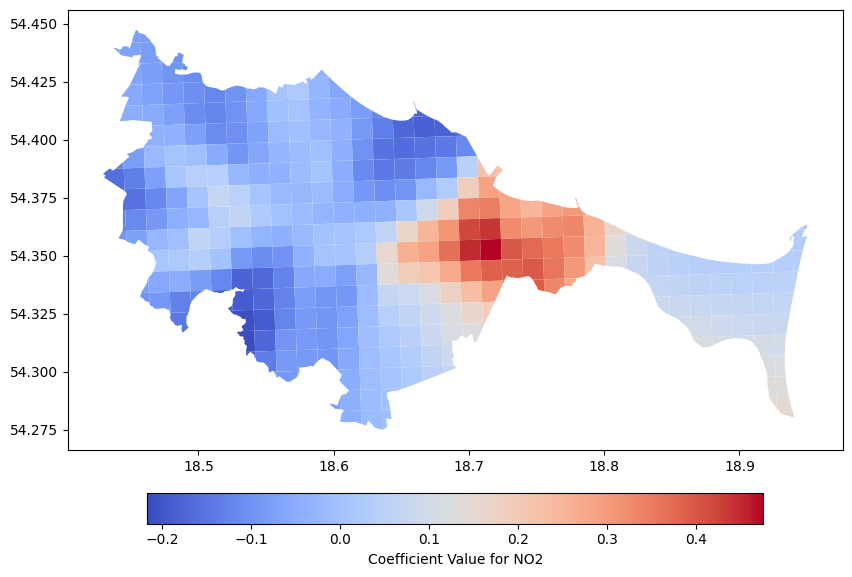

In [ ]:
# Assuming the 9th variable is lst_mean (after intercept in X)
gdf_gwlr['coef_nox_mean'] = gwr_model.params[:, 5]

# Plot the spatial variability of 'lst_mean' coefficient
fig, ax = plt.subplots(figsize=(10, 8))  # Set figure size

# Create the plot
gdf = gdf_gwlr.plot(
    column='coef_nox_mean',
    cmap='coolwarm',
    legend=False,
    ax=ax
)

# Add a colorbar below the map
sm = cm.ScalarMappable(cmap='coolwarm', norm=mcolors.Normalize(vmin=gdf_gwlr['coef_nox_mean'].min(), vmax=gdf_gwlr['coef_nox_mean'].max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.05, pad=0.07)
cbar.set_label("Coefficient Value for NO2")

# Add other map settings
# ax.set_title("Spatial Variability of Coefficient for LST", fontsize=14)
ax.axis('on')

# Display the plot
plt.show()
# fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/coef_nox_mean.jpg',bbox_inches="tight", dpi=300)
# files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/coef_nox_mean.jpg")

#### T-value plots

In [ ]:
# Function to dynamically classify t-values into bins
def classify_t_values_dynamic(t_values, num_bins):
    """
    Dynamically classify t-values into bins.

    Parameters:
    - t_values: A pandas Series or NumPy array of t-values.
    - num_bins: Number of bins for classification.

    Returns:
    - categories: A list of categories for each value.
    - labels: Labels for the legend.
    - bins: Bin edges.
    """
    # Create bins
    bins = np.linspace(t_values.min(), t_values.max(), num_bins + 1)
    labels = [f"{bins[i]:.2f} to {bins[i+1]:.2f}" for i in range(len(bins) - 1)]
    categories = np.digitize(t_values, bins) - 1  # -1 to make categories 0-indexed
    categories[categories >= num_bins] = num_bins - 1  # Handle edge case for max value
    return categories, labels, bins

# Function to plot t-values with a dynamic legend
def plot_t_values_dynamic_with_custom_colors(geodf, column_name, variable_label, num_bins=5, custom_colors=None):
    """
    Plot a GeoDataFrame with t-values dynamically classified into bins and custom colors.

    Parameters:
    - geodf: GeoDataFrame containing the data.
    - column_name: The column with t-values to be plotted.
    - variable_label: The label of the variable (used for titles and legend titles).
    - num_bins: Number of bins to divide the t-values into.
    - custom_colors: List of custom colors for the bins. Must match the number of bins.
    """
    # Dynamically classify t-values
    t_values = geodf[column_name]
    categories, labels, bins = classify_t_values_dynamic(t_values, num_bins)
    geodf['category'] = categories

    # Use custom colors or fallback to default
    if custom_colors is None:
        # Default colors if none are provided
        custom_colors = ['#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f']

    if len(custom_colors) != num_bins:
        raise ValueError("Number of custom colors must match the number of bins.")

    # Plot the map
    fig, ax = plt.subplots(figsize=(10, 8))
    geodf.plot(column='category', color=[custom_colors[i] for i in categories], ax=ax)
    ax.axis('on')

    # Create a dynamic legend
    patches = [mpatches.Patch(color=custom_colors[i], label=label) for i, label in enumerate(labels)]
    ax.legend(handles=patches, title=f"T-values: {variable_label}", loc='upper right', frameon=True)

    # Show the plot
    plt.title(f"Spatial Distribution of T-Values for {variable_label}")
    plt.show()
    fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/t-value_pop_den.jpg',bbox_inches="tight", dpi=300)
    files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/t-value_pop_den.jpg")

# Example Usage with Custom Colors
custom_colors_imper_area = ['#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f']  # Define your colors
plot_t_values_dynamic_with_custom_colors(
    gdf_gwlr,
    column_name='t_values_pop_den_mean',  # Replace with the t-value column for a specific factor
    variable_label='Pop. density',
    num_bins=5,  # Number of bins for classification
    custom_colors=custom_colors_imper_area  # Use custom colors
)
# ['#ffffd9','#c6e9b3', '#40b6c4', '#225ea7', '#081c57']
# variable_descriptions = [
#     'Elderly pop.', 'Distance from river network', 'Distance from rainwater collectors', 'Ozone', 'NO2',
#     'Pop. density', 'DEM', 'LST', 'NDVI', 'Impervious area',
#     'Historical floods', 'RCP4.5 (2071-2100)', 'RCP8.5 (2021-2050)', 'RCP8.5 (2071-2100)',
#     'Health services', 'Educational institutes', 'Industries']
# variables = ['Intercept', 'elderly_mean', 'river_mean', 'rainw_mean', 'ozone_mean', 'nox_mean', 'pop_den_mean',
#              'DEM_mean', 'lst_mean', 'ndvi_mean', 'imper_area', 'flood_count', 'pr1_71_2100_mean',
#              'pr2_21_50_mean', 'pr2_71_2100_mean', 'health_mean', 'educ_mean', 'indus_mean']

# Types of GI in Gdansk chart

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3), subplot_kw=dict(aspect="equal"))

types = [ "Forest and semi-forest greenery",
          "Riparian and aquatic greenery",
          "Recreational greenery",
          "Agriculture",
          "Other green areas"
]

data = [46, 9, 7, 33, 4]

# Colors matching the image
colors = [
    "#4F9E87",  # dark green
    "#BDEFE3",  # light cyan
    "#B9E45A",  # light green
    "#F1F27A",  # yellow
    "#F2C572"   # orange
]

wedges, texts = ax.pie(
    data,
    colors=colors,
    wedgeprops=dict(width=0.5),
    startangle=-40
)

# ---- outer labels (UNCHANGED STYLE) ----
bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
kw = dict(
    arrowprops=dict(arrowstyle="-"),
    bbox=bbox_props,
    zorder=0,
    va="center"
)

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})

    ax.annotate(
        types[i],
        xy=(x, y),
        xytext=(1.35*np.sign(x), 1.4*y),
        horizontalalignment=horizontalalignment,
        **kw
    )

    # ---- data labels inside donut (NEW) ----
    ax.text(
        0.75 * x,
        0.75 * y,
        f"{data[i]}%",
        ha="center",
        va="center",
        fontsize=12,
        color="black",
        weight="bold"
    )

ax.set_title("")
plt.show()
fig.savefig('/content/drive/MyDrive/GI mapping/Grid scale GI mapping/pie_chart.jpg',bbox_inches="tight", dpi=400)
files.download("/content/drive/MyDrive/GI mapping/Grid scale GI mapping/pie_chart.jpg")

# GI priority Areas Map

To enhance the practical relevance of the analysis, a GI priority map is developed.

Priority areas are identified based on the co-occurrence of low GI density and high environmental stress. GI density values below the 25th percentile are classified as low supply, while environmental stress indicators above the 75th percentile are classified as high stress.

Cells meeting these conditions, particularly those with multiple stress indicators, are classified as high-priority intervention areas.

This approach supports strategic planning by identifying areas where GI implementation could deliver the greatest environmental benefits.

In [ ]:
import pandas as pd

def percentile_rank(series):
    return series.rank(pct=True)

# Percentiles for GI (supply)
combined_gdf_copy['p_GI'] = percentile_rank(combined_gdf_copy['GI_density'])

# Percentiles for stress indicators
combined_gdf_copy['p_LST'] = percentile_rank(combined_gdf_copy['lst_mean'])
combined_gdf_copy['p_imperv'] = percentile_rank(combined_gdf_copy['imper_area'])
combined_gdf_copy['p_flood'] = percentile_rank(combined_gdf_copy['flood_count'])

# Optional air quality
combined_gdf_copy['p_NO2'] = percentile_rank(combined_gdf_copy['nox_mean'])


In [ ]:
# GI deficit = lowest 25%
combined_gdf_copy['low_GI'] = (combined_gdf_copy['p_GI'] <= 0.25).astype(int)

# High stress = highest 25%
combined_gdf_copy['high_LST'] = (combined_gdf_copy['p_LST'] >= 0.75).astype(int)
combined_gdf_copy['high_imperv'] = (combined_gdf_copy['p_imperv'] >= 0.75).astype(int)
combined_gdf_copy['high_flood'] = (combined_gdf_copy['p_flood'] >= 0.75).astype(int)
combined_gdf_copy['high_NO2'] = (combined_gdf_copy['p_NO2'] >= 0.75).astype(int)


In [ ]:
combined_gdf_copy['stress_count'] = (
    combined_gdf_copy['high_LST'] +
    combined_gdf_copy['high_imperv'] +
    combined_gdf_copy['high_flood'] +
    combined_gdf_copy['high_NO2']
)


In [ ]:
combined_gdf_copy['priority_GI'] = (
    (combined_gdf_copy['low_GI'] == 1) &
    (combined_gdf_copy['stress_count'] >= 2)
).astype(int)


In [ ]:
combined_gdf_copy['priority_GI'].value_counts()
combined_gdf_copy[['low_GI', 'stress_count']].describe()


In [ ]:
# to show priority areas as map

fig, ax = plt.subplots(figsize=(8, 6))

# Plot non-priority cells
combined_gdf_copy[combined_gdf_copy['priority_GI'] == 0].plot(
    ax=ax,
    color='lightgrey',
    edgecolor='none',
    alpha=0.7,
    label='Non-priority'
)

# Plot priority cells
combined_gdf_copy[combined_gdf_copy['priority_GI'] == 1].plot(
    ax=ax,
    color='#d73027',  # red
    edgecolor='red',
    linewidth=0.2,
    label='Priority GI intervention'
)

ax.set_title('Priority areas for green infrastructure intervention (1 km grid)', fontsize=12)
ax.set_axis_off()
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()
